In [1]:
%load_ext autotime

import scarf
import matplotlib.pyplot as plt
import pandas as pd

scarf.__version__

'1.0.0'

time: 3.1 s (started: 2026-06-25 23:24:48 +02:00)


In [2]:
scarf.fetch_dataset("lecun_60K_mnist_images", save_path="scarf_datasets")

time: 33 s (started: 2026-06-25 23:24:52 +02:00)


In [3]:
reader = scarf.CrDirReader("scarf_datasets/lecun_60K_mnist_images")
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/lecun_60K_mnist_images/data.zarr",
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=14, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=9, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. A

  0%|                                                                                                         …

time: 15.9 s (started: 2026-06-25 23:25:25 +02:00)


In [4]:
ds = scarf.DataStore(
    "scarf_datasets/lecun_60K_mnist_images/data.zarr",
    min_cells_per_feature=1000,
    min_features_per_cell=10,
    nthreads=4,
)
ds

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

DataStore has 60000 (60000) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nFeatures', 'RNA_nCounts', 
          
   RNA assay has 467 (784) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 2.75 s (started: 2026-06-25 23:25:40 +02:00)


In [5]:
ds.cells.insert(
    "digit_label",
    [int(x.rsplit("_", 1)[-1]) - 1 for x in ds.cells.fetch_all("names")],
    overwrite=True,
)

time: 147 ms (started: 2026-06-25 23:25:43 +02:00)


Writing data to normed__I__I/data:   0%|                                                                      …

Calculating mean of norm. data:   0%|                                                                         …

Calculating std. dev. of norm. data:   0%|                                                                    …

Fitting PCA:   0%|                                                                                            …

Fitting ANN:   0%|                                                                                            …

Fitting kmeans:   0%|                                                                                         …

Estimating seed partitions:   0%|                                                                             …

Identifying neighbors:   0%|                                                                                  …

Smoothening KNN distances:   0%|                                                                              …

INFO: ANN recall: 100.00%


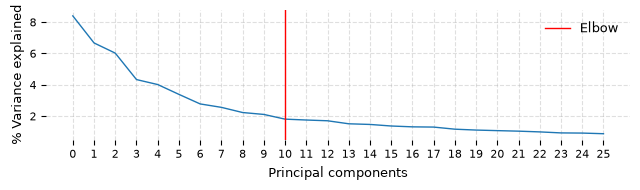

time: 1min 3s (started: 2026-06-25 23:25:43 +02:00)


In [6]:
# Set normalization method to a dummy function that returns unnormalized data
ds.RNA.normMethod = scarf.assay.norm_dummy

ds.make_graph(feat_key="I", k=31, dims=25, n_centroids=100, show_elbow_plot=True)

In [7]:
ds.run_umap(n_epochs=300, spread=1, min_dist=0.05, parallel=True)

Training UMAP:   0%|                                                                                          …

	completed  0  /  300 epochs


	completed  30  /  300 epochs


	completed  60  /  300 epochs


	completed  90  /  300 epochs


...

	completed  180  /  300 epochs


	completed  210  /  300 epochs


	completed  240  /  300 epochs


	completed  270  /  300 epochs


time: 1min 2s (started: 2026-06-25 23:26:47 +02:00)


In [8]:
ds.run_clustering(n_clusters=20)

time: 18.8 s (started: 2026-06-25 23:27:50 +02:00)


In [9]:
ds.smart_label(
    to_relabel="RNA_cluster",
    base_label="digit_label",
    new_col_name="cluster_label",
)

time: 182 ms (started: 2026-06-25 23:28:09 +02:00)


/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=2, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


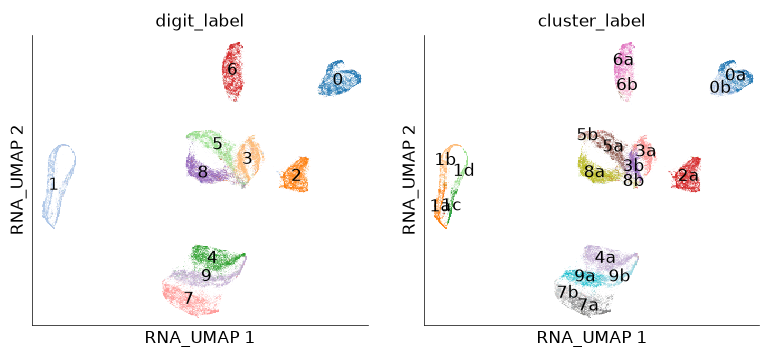

time: 2.16 s (started: 2026-06-25 23:28:09 +02:00)


In [10]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by=["digit_label", "cluster_label"],
    do_shading=True,
    shade_npixels=300,
    legend_onside=False,
    width=4,
    height=4,
    cmap="tab20",
)

Constructing graph from dendrogram:   0%|                                                                     …

Identifying the top node for cluster:   0%|                                                                   …

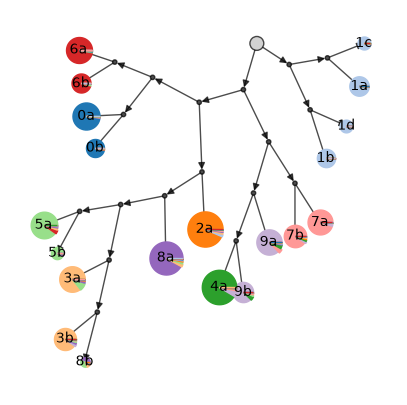

time: 2.74 s (started: 2026-06-25 23:28:11 +02:00)


In [11]:
ds.plot_cluster_tree(
    cluster_key="cluster_label",
    fill_by_value="digit_label",
)

In [12]:
clusts = pd.Series(ds.cells.fetch_all("cluster_label"))
digits = pd.Series(ds.cells.fetch_all("digit_label"))

time: 42.4 ms (started: 2026-06-25 23:28:14 +02:00)


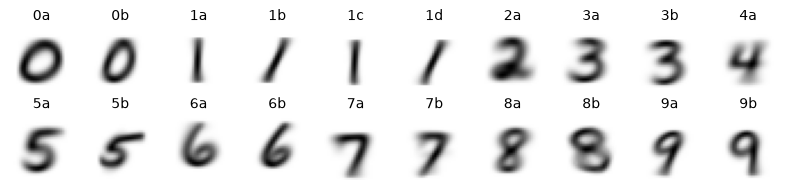

time: 3.87 s (started: 2026-06-25 23:28:14 +02:00)


In [13]:
fig = plt.figure(figsize=(8, 2))
for n, i in enumerate(sorted(clusts.unique())):
    mean_map = ds.RNA.rawData[((clusts == i) & (digits == int(i[0]))).values].mean(
        axis=0
    )
    mean_map = mean_map.compute().reshape(28, 28)
    ax = fig.add_subplot(2, 10, n + 1)
    ax.imshow(mean_map, cmap="binary")
    ax.set_axis_off()
    ax.set_title(i, fontsize=10)
plt.tight_layout()
plt.show()